ERROR 1: PROJ: proj_create_from_database: Open of /jupyterhq/miniconda3/envs/main/share/proj failed


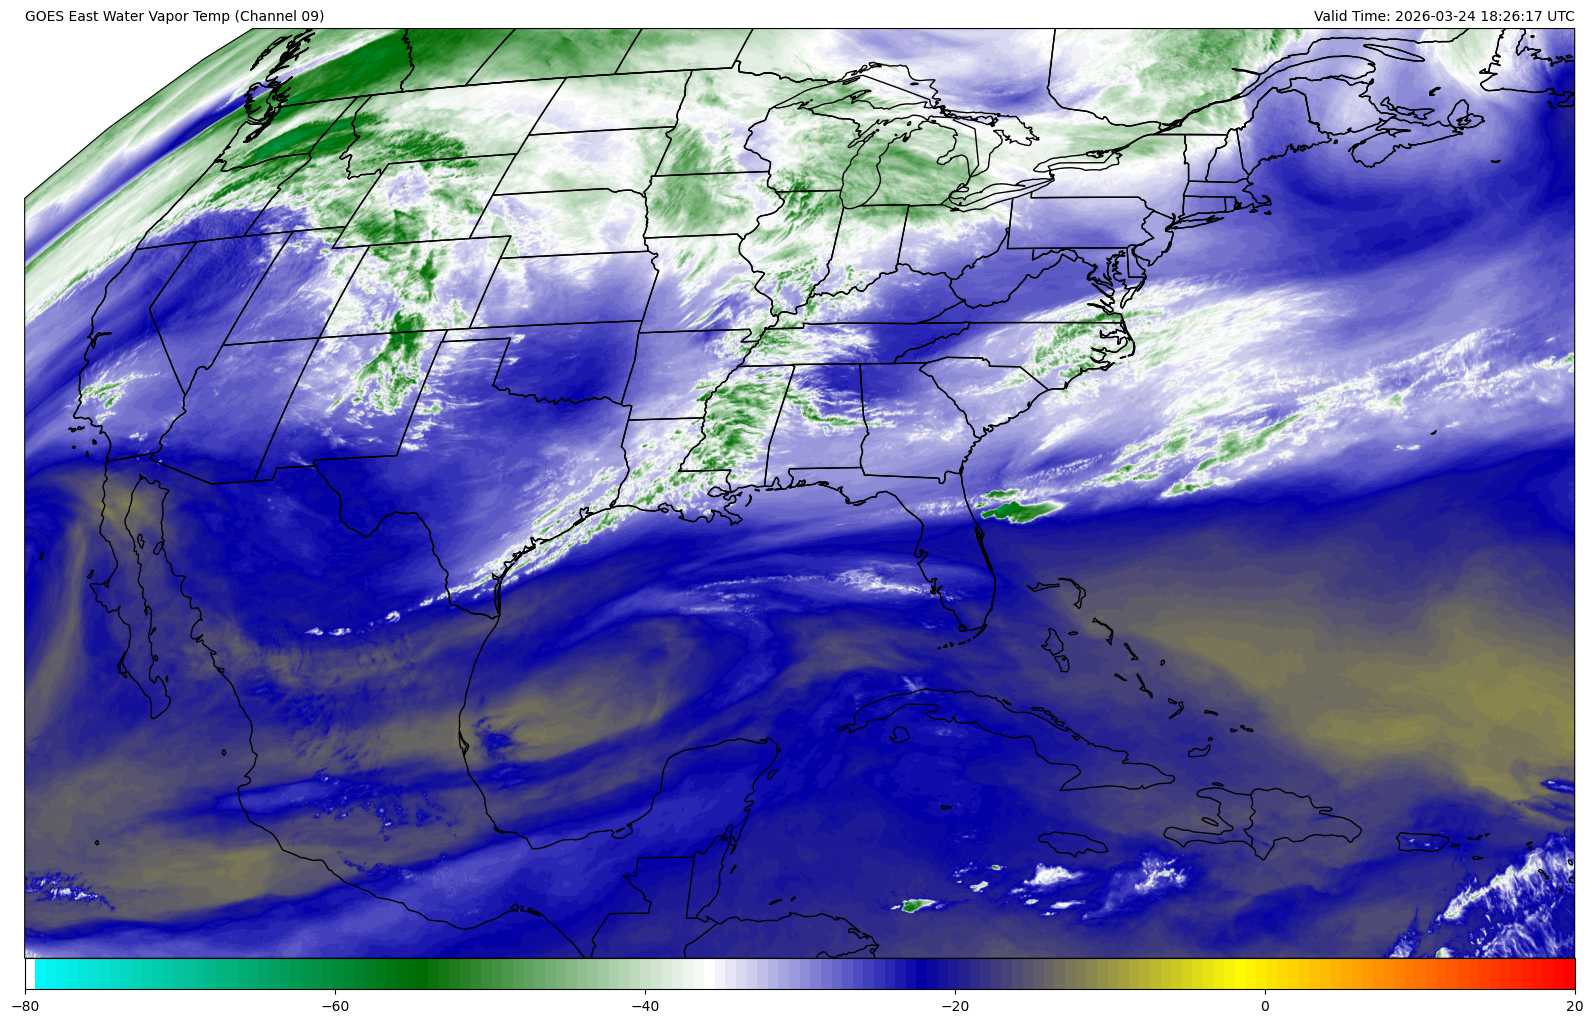

In [1]:
from datetime import datetime, UTC

from metpy.plots import declarative
import numpy as np
from siphon.catalog import TDSCatalog

# Current time
date = datetime.now(UTC).replace(tzinfo=None)

# Settings
region = 'CONUS'
channel = 9
satellite = 'east'

# Build data URL
data_url = (f'https://thredds.ucar.edu/thredds/catalog/satellite/goes/{satellite}/'
            f'products/CloudAndMoistureImagery/{region}/Channel{channel:02d}/'
            f'{date:%Y%m%d}/catalog.xml')

# Access catalog
cat = TDSCatalog(data_url)

# Get closest dataset in time
dataset = cat.datasets.filter_time_nearest(
    date,
    regex=r'_s(?P<strptime>\d{13})',
    strptime='%Y%j%H%M%S'
)

# Open dataset
ds = dataset.remote_access(service='OPENDAP', use_xarray=True)

# ✅ Convert brightness temperature (K → °C)
ds['WVT_C'] = ds['Sectorized_CMI'] - 273.15

# Apply correction ONLY for visible channel
if channel == 2:
    ds['Sectorized_CMI'].values = np.sqrt(ds['Sectorized_CMI'].values)

# Get valid time
vtime = ds.time.values.astype('datetime64[ms]').astype('O')

# ------------------ PLOTTING ------------------

# Create image plot
img = declarative.ImagePlot()
img.data = ds
img.field = 'WVT_C'   # ✅ use temperature in °C
img.colormap = 'WVCIMSS_r'
img.colorbar = 'horizontal'
img.image_range = (-80, 20)

# Map panel
panel = declarative.MapPanel()
panel.layers = ['coastline', 'borders', 'states']
panel.left_title = f'GOES East Water Vapor Temp (Channel {channel:02d})'
panel.right_title = f'Valid Time: {vtime} UTC'
panel.plots = [img]

# Figure container
pc = declarative.PanelContainer()
pc.size = (20, 16)
pc.panels = [panel]

# Show plot
pc.show()